# 02 Baseline U-Net

This notebook implements the baseline U-Net model using the processed STRUM RGB dataset.

Input:
- RGB Sentinel-2 images
- Shape: (3,128,128)

Output:
- Binary flood segmentation mask
- Shape: (1,128,128)

The baseline model will be used for comparison against the Hybrid SAM-U-Net architecture.

In [64]:
import os
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

In [65]:
import sys
import torch

print(sys.executable)
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

c:\Users\KRITHI S KULAL\Desktop\TECH\UNET+HYBRID_MODEL\venv\Scripts\python.exe
2.12.0+cu126
12.6
True


In [66]:
print(torch.cuda.get_device_name(0))

NVIDIA GeForce RTX 2050


In [67]:
DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

IMAGE_SIZE = 128

BATCH_SIZE = 8

LEARNING_RATE = 1e-4

EPOCHS = 80

Device: cuda


In [68]:
PROCESSED_PATH = Path(
    "../dataset/processed/STRUM"
)

TRAIN_IMAGE_DIR = (
    PROCESSED_PATH /
    "train" /
    "images"
)

TRAIN_MASK_DIR = (
    PROCESSED_PATH /
    "train" /
    "masks"
)

VAL_IMAGE_DIR = (
    PROCESSED_PATH /
    "val" /
    "images"
)

VAL_MASK_DIR = (
    PROCESSED_PATH /
    "val" /
    "masks"
)

TEST_IMAGE_DIR = (
    PROCESSED_PATH /
    "test" /
    "images"
)

TEST_MASK_DIR = (
    PROCESSED_PATH /
    "test" /
    "masks"
)

In [69]:
train_images = sorted(
    list(TRAIN_IMAGE_DIR.glob("*.npy"))
)

train_masks = sorted(
    list(TRAIN_MASK_DIR.glob("*.npy"))
)

print("Train Images:", len(train_images))
print("Train Masks :", len(train_masks))

Train Images: 2140
Train Masks : 2140


In [70]:
sample_image = np.load(
    train_images[0]
)

sample_mask = np.load(
    train_masks[0]
)

print("Image Shape :", sample_image.shape)
print("Mask Shape  :", sample_mask.shape)

print("Image Min   :", sample_image.min())
print("Image Max   :", sample_image.max())

print("Mask Classes:", np.unique(sample_mask))

Image Shape : (3, 128, 128)
Mask Shape  : (128, 128)
Image Min   : 0.0
Image Max   : 1.0
Mask Classes: [0 1]


In [71]:
print(
    "Image Has NaN:",
    np.isnan(sample_image).any()
)

print(
    "Image Has Inf:",
    np.isinf(sample_image).any()
)

print(
    "Mask Has NaN:",
    np.isnan(sample_mask).any()
)

Image Has NaN: False
Image Has Inf: False
Mask Has NaN: False


In [72]:
bad_images = 0

for file in train_images:

    image = np.load(file)

    if np.isnan(image).any():

        bad_images += 1

print(
    "Images Containing NaN:",
    bad_images
)

Images Containing NaN: 0


In [52]:
sample_image.shape
sample_mask.shape

sample_image.min()
sample_image.max()

np.unique(sample_mask)

array([0, 1], dtype=uint8)

In [76]:
bad_files = []

for file in train_images:

    image = np.load(file)

    if np.isnan(image).any():

        bad_files.append(file)

print("Bad Files Found:", len(bad_files))

for f in bad_files:
    print(f)

Bad Files Found: 0


In [121]:
x = torch.randn(
    1,
    3,
    128,
    128
).to(DEVICE)

with torch.no_grad():

    y = model(x)

print(y.shape)

torch.Size([1, 1, 128, 128])


In [122]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"Parameters: {total_params:,}"
)

Parameters: 31,037,633


## Dataset Class

Loads processed RGB images and binary masks from the processed STRUM dataset.

In [123]:
class FloodDataset(Dataset):

    def __init__(self, image_dir, mask_dir):

        self.images = sorted(
            list(Path(image_dir).glob("*.npy"))
        )

        self.masks = sorted(
            list(Path(mask_dir).glob("*.npy"))
        )

    def __len__(self):

        return len(self.images)

    def __getitem__(self, idx):

        # Load image
        image = np.load(
            self.images[idx]
        )

        # Load mask
        mask = np.load(
            self.masks[idx]
        )

        # Add channel dimension to mask
        # (128,128) -> (1,128,128)
        mask = np.expand_dims(
            mask,
            axis=0
        )

        # Convert to tensors
        image = torch.tensor(
            image,
            dtype=torch.float32
        )

        mask = torch.tensor(
            mask,
            dtype=torch.float32
        )

        return image, mask

In [124]:
train_dataset = FloodDataset(
    TRAIN_IMAGE_DIR,
    TRAIN_MASK_DIR
)

val_dataset = FloodDataset(
    VAL_IMAGE_DIR,
    VAL_MASK_DIR
)

test_dataset = FloodDataset(
    TEST_IMAGE_DIR,
    TEST_MASK_DIR
)

print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

Train: 2140
Val  : 267
Test : 268


In [88]:
image, mask = train_dataset[0]

print("Image Shape:", image.shape)
print("Mask Shape :", mask.shape)

print("Image Min :", image.min())
print("Image Max :", image.max())

print("Mask Classes:")
print(torch.unique(mask))

Image Shape: torch.Size([3, 128, 128])
Mask Shape : torch.Size([1, 128, 128])
Image Min : tensor(0.)
Image Max : tensor(1.)
Mask Classes:
tensor([0., 1.])


In [125]:
images, masks = next(iter(train_loader))

print(images.shape)
print(masks.shape)

print(torch.unique(masks))

torch.Size([8, 3, 128, 128])
torch.Size([8, 1, 128, 128])
tensor([0., 1.])


## U-Net Architecture

Baseline U-Net for binary flood segmentation.

Input:
- RGB Image (3×128×128)

Output:
- Binary Flood Mask (1×128×128)

In [126]:
class DoubleConv(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels
    ):

        super().__init__()

        self.conv = nn.Sequential(

            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False
            ),

            nn.BatchNorm2d(
                out_channels
            ),

            nn.ReLU(inplace=True)

        )

    def forward(self, x):

        return self.conv(x)

In [127]:
class UNet(nn.Module):

    def __init__(
        self,
        in_channels=3,
        out_channels=1
    ):

        super().__init__()

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        # Encoder

        self.down1 = DoubleConv(
            in_channels,
            64
        )

        self.down2 = DoubleConv(
            64,
            128
        )

        self.down3 = DoubleConv(
            128,
            256
        )

        self.down4 = DoubleConv(
            256,
            512
        )

        # Bottleneck

        self.bottleneck = DoubleConv(
            512,
            1024
        )

        # Decoder

        self.up4 = nn.ConvTranspose2d(
            1024,
            512,
            kernel_size=2,
            stride=2
        )

        self.dec4 = DoubleConv(
            1024,
            512
        )

        self.up3 = nn.ConvTranspose2d(
            512,
            256,
            kernel_size=2,
            stride=2
        )

        self.dec3 = DoubleConv(
            512,
            256
        )

        self.up2 = nn.ConvTranspose2d(
            256,
            128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = DoubleConv(
            256,
            128
        )

        self.up1 = nn.ConvTranspose2d(
            128,
            64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = DoubleConv(
            128,
            64
        )

        self.final = nn.Conv2d(
            64,
            out_channels,
            kernel_size=1
        )

    def forward(self, x):

        d1 = self.down1(x)

        d2 = self.down2(
            self.pool(d1)
        )

        d3 = self.down3(
            self.pool(d2)
        )

        d4 = self.down4(
            self.pool(d3)
        )

        bottleneck = self.bottleneck(
            self.pool(d4)
        )

        u4 = self.up4(
            bottleneck
        )

        u4 = torch.cat(
            [u4, d4],
            dim=1
        )

        u4 = self.dec4(u4)

        u3 = self.up3(u4)

        u3 = torch.cat(
            [u3, d3],
            dim=1
        )

        u3 = self.dec3(u3)

        u2 = self.up2(u3)

        u2 = torch.cat(
            [u2, d2],
            dim=1
        )

        u2 = self.dec2(u2)

        u1 = self.up1(u2)

        u1 = torch.cat(
            [u1, d1],
            dim=1
        )

        u1 = self.dec1(u1)

        return self.final(u1)

In [92]:
model = UNet().to(DEVICE)

print(model)

UNet(
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (down1): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down2): DoubleConv(
    (conv): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(128, eps=1e-05, momentum=0.

In [93]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print(outputs.shape)

print(
    outputs.min()
)

print(
    outputs.max()
)

print(
    torch.isnan(outputs).any()
)

torch.Size([8, 1, 128, 128])
tensor(-4.1048, device='cuda:0')
tensor(0.9064, device='cuda:0')
tensor(False, device='cuda:0')


In [94]:
class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-6
    ):

        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probs = torch.sigmoid(
            logits
        )

        probs = probs.view(-1)

        targets = targets.view(-1)

        intersection = (
            probs * targets
        ).sum()

        dice = (
            2.0 * intersection
            + self.smooth
        ) / (
            probs.sum()
            + targets.sum()
            + self.smooth
        )

        return 1 - dice

In [95]:
class BCEDiceLoss(nn.Module):

    def __init__(self):

        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()

        self.dice = DiceLoss()

    def forward(
        self,
        logits,
        targets
    ):

        bce_loss = self.bce(
            logits,
            targets
        )

        dice_loss = self.dice(
            logits,
            targets
        )

        return (
            bce_loss
            + dice_loss
        )

In [96]:
def compute_iou(
    logits,
    targets,
    threshold=0.5
):

    probs = torch.sigmoid(
        logits
    )

    preds = (
        probs > threshold
    ).float()

    intersection = (
        preds * targets
    ).sum()

    union = (
        preds + targets
    ).sum() - intersection

    iou = (
        intersection + 1e-6
    ) / (
        union + 1e-6
    )

    return iou.item()

In [98]:
criterion = BCEDiceLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-4
)

In [99]:
#Sanity Check Before Training
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)
masks = masks.to(DEVICE)

outputs = model(images)

loss = criterion(
    outputs,
    masks
)

print(
    "Loss:",
    loss.item()
)

print(
    "NaN Loss:",
    torch.isnan(loss)
)

Loss: 1.433261752128601
NaN Loss: tensor(False, device='cuda:0')


In [100]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    epoch_loss = 0.0
    epoch_iou = 0.0

    for images, masks in tqdm(
        loader,
        desc="Training",
        leave=False
    ):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            masks
        )

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

        epoch_iou += compute_iou(
            outputs.detach(),
            masks
        )

    epoch_loss /= len(loader)

    epoch_iou /= len(loader)

    return epoch_loss, epoch_iou

In [101]:
def validate_one_epoch(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    epoch_loss = 0.0
    epoch_iou = 0.0

    with torch.no_grad():

        for images, masks in tqdm(
            loader,
            desc="Validation",
            leave=False
        ):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            epoch_loss += loss.item()

            epoch_iou += compute_iou(
                outputs,
                masks
            )

    epoch_loss /= len(loader)

    epoch_iou /= len(loader)

    return epoch_loss, epoch_iou

In [109]:
train_losses = []
val_losses = []

train_ious = []
val_ious = []

best_val_iou = 0.0

In [106]:
CHECKPOINT_PATH = (
    "../checkpoints/best_unet.pth"
)

In [110]:
EPOCHS = 80

for epoch in range(EPOCHS):

    train_loss, train_iou = train_one_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        DEVICE
    )

    val_loss, val_iou = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_ious.append(train_iou)
    val_ious.append(val_iou)

    improved = False

    if val_iou > best_val_iou:

        best_val_iou = val_iou

        torch.save(
            model.state_dict(),
            CHECKPOINT_PATH
        )

        improved = True

    print(
        f"Epoch [{epoch+1:03d}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val IoU: {val_iou:.4f}"
        +
        (" | Best ✓" if improved else "")
    )

Epoch [001/80] | Train Loss: 0.9188 | Val Loss: 0.9831 | Val IoU: 0.3705 | Best ✓


Epoch [002/80] | Train Loss: 0.8987 | Val Loss: 0.9611 | Val IoU: 0.3860 | Best ✓


Epoch [003/80] | Train Loss: 0.8756 | Val Loss: 0.9264 | Val IoU: 0.3957 | Best ✓


Epoch [004/80] | Train Loss: 0.8413 | Val Loss: 0.8611 | Val IoU: 0.4426 | Best ✓


Epoch [005/80] | Train Loss: 0.8181 | Val Loss: 0.8442 | Val IoU: 0.4251


...

Epoch [076/80] | Train Loss: 0.3342 | Val Loss: 0.6555 | Val IoU: 0.5726


Epoch [077/80] | Train Loss: 0.3597 | Val Loss: 0.6315 | Val IoU: 0.5757


Epoch [078/80] | Train Loss: 0.3285 | Val Loss: 0.6433 | Val IoU: 0.5781


Epoch [079/80] | Train Loss: 0.3366 | Val Loss: 0.6579 | Val IoU: 0.5696


Epoch [080/80] | Train Loss: 0.3348 | Val Loss: 0.6565 | Val IoU: 0.5679


In [111]:
print("Best Validation IoU:", best_val_iou)

print("Final Train Loss:", train_losses[-1])

print("Final Val Loss:", val_losses[-1])

print("Final Train IoU:", train_ious[-1])

print("Final Val IoU:", val_ious[-1])

Best Validation IoU: 0.5797433385882601
Final Train Loss: 0.33477719567382513
Final Val Loss: 0.6565160155296326
Final Train IoU: 0.7790787600314439
Final Val IoU: 0.5679151903138797


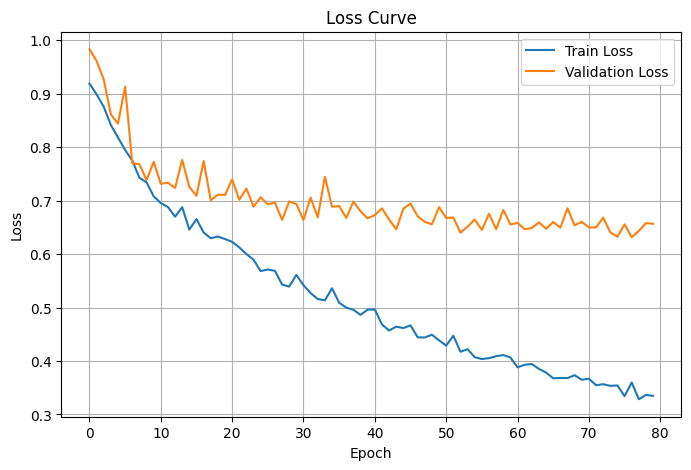

In [112]:
plt.figure(figsize=(8,5))

plt.plot(
    train_losses,
    label="Train Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Loss Curve")

plt.legend()

plt.grid()

plt.show()

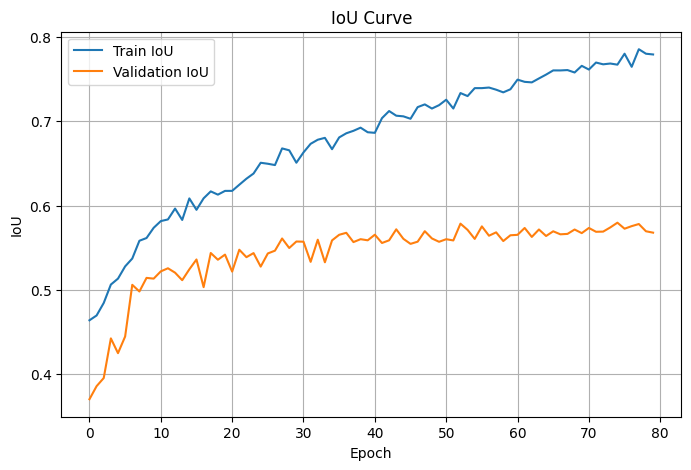

In [113]:
plt.figure(figsize=(8,5))

plt.plot(
    train_ious,
    label="Train IoU"
)

plt.plot(
    val_ious,
    label="Validation IoU"
)

plt.xlabel("Epoch")

plt.ylabel("IoU")

plt.title("IoU Curve")

plt.legend()

plt.grid()

plt.show()

In [116]:
best_val_iou

val_ious[-10:]

[0.5734796084555784,
 0.5689478541926789,
 0.5691613749217067,
 0.5741244877301367,
 0.5797433385882601,
 0.5726010214523686,
 0.5756510168199277,
 0.5781421725442397,
 0.569566008631849,
 0.5679151903138797]

In [117]:
model = UNet().to(DEVICE)

model.load_state_dict(
    torch.load(
        "../checkpoints/best_unet.pth",
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded.")

Best model loaded.


### Evaluation metrics

In [118]:
def evaluate_model(
    model,
    loader,
    device
):

    model.eval()

    all_preds = []
    all_targets = []

    with torch.no_grad():

        for images, masks in tqdm(loader):

            images = images.to(device)

            outputs = model(images)

            preds = (
                torch.sigmoid(outputs) > 0.5
            ).float()

            all_preds.extend(
                preds.cpu().numpy().flatten()
            )

            all_targets.extend(
                masks.numpy().flatten()
            )

    accuracy = accuracy_score(
        all_targets,
        all_preds
    )

    precision = precision_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    recall = recall_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    f1 = f1_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    iou = jaccard_score(
        all_targets,
        all_preds,
        zero_division=0
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "IoU": iou
    }

In [128]:
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=0
)

In [130]:
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

2140
267
268


In [129]:
results = evaluate_model(
    model,
    test_loader,
    DEVICE
)

for metric, value in results.items():

    print(
        f"{metric}: {value:.4f}"
    )

  0%|          | 0/34 [00:00<?, ?it/s]

100%|██████████| 34/34 [00:11<00:00,  2.89it/s]


Accuracy: 0.9050
Precision: 0.8135
Recall: 0.8084
F1: 0.8109
IoU: 0.6820


In [131]:
dice = (
    2 * results["Precision"] * results["Recall"]
) / (
    results["Precision"]
    + results["Recall"]
    + 1e-8
)

print(
    f"Dice Score: {dice:.4f}"
)

Dice Score: 0.8109


In [133]:
import pandas as pd
metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1",
            "Dice",
            "IoU"
        ],
        "Value": [
            results["Accuracy"],
            results["Precision"],
            results["Recall"],
            results["F1"],
            dice,
            results["IoU"]
        ]
    }
)

metrics_df

,Metric,Value
0,Accuracy,0.905005
1,Precision,0.813498
2,Recall,0.808389
3,F1,0.810935
4,Dice,0.810935
5,IoU,0.681994


In [134]:
def visualize_predictions(
    model,
    dataset,
    device,
    num_samples=5
):

    model.eval()

    fig, axes = plt.subplots(
        num_samples,
        3,
        figsize=(12, 4*num_samples)
    )

    with torch.no_grad():

        for i in range(num_samples):

            image, mask = dataset[i]

            pred = model(
                image.unsqueeze(0).to(device)
            )

            pred = (
                torch.sigmoid(pred)
                > 0.5
            ).float()

            rgb = image.permute(
                1,2,0
            ).numpy()

            axes[i,0].imshow(rgb)
            axes[i,0].set_title("RGB")

            axes[i,1].imshow(
                mask.squeeze(),
                cmap="Blues"
            )
            axes[i,1].set_title("Ground Truth")

            axes[i,2].imshow(
                pred.squeeze().cpu(),
                cmap="Blues"
            )
            axes[i,2].set_title("Prediction")

    plt.tight_layout()
    plt.show()

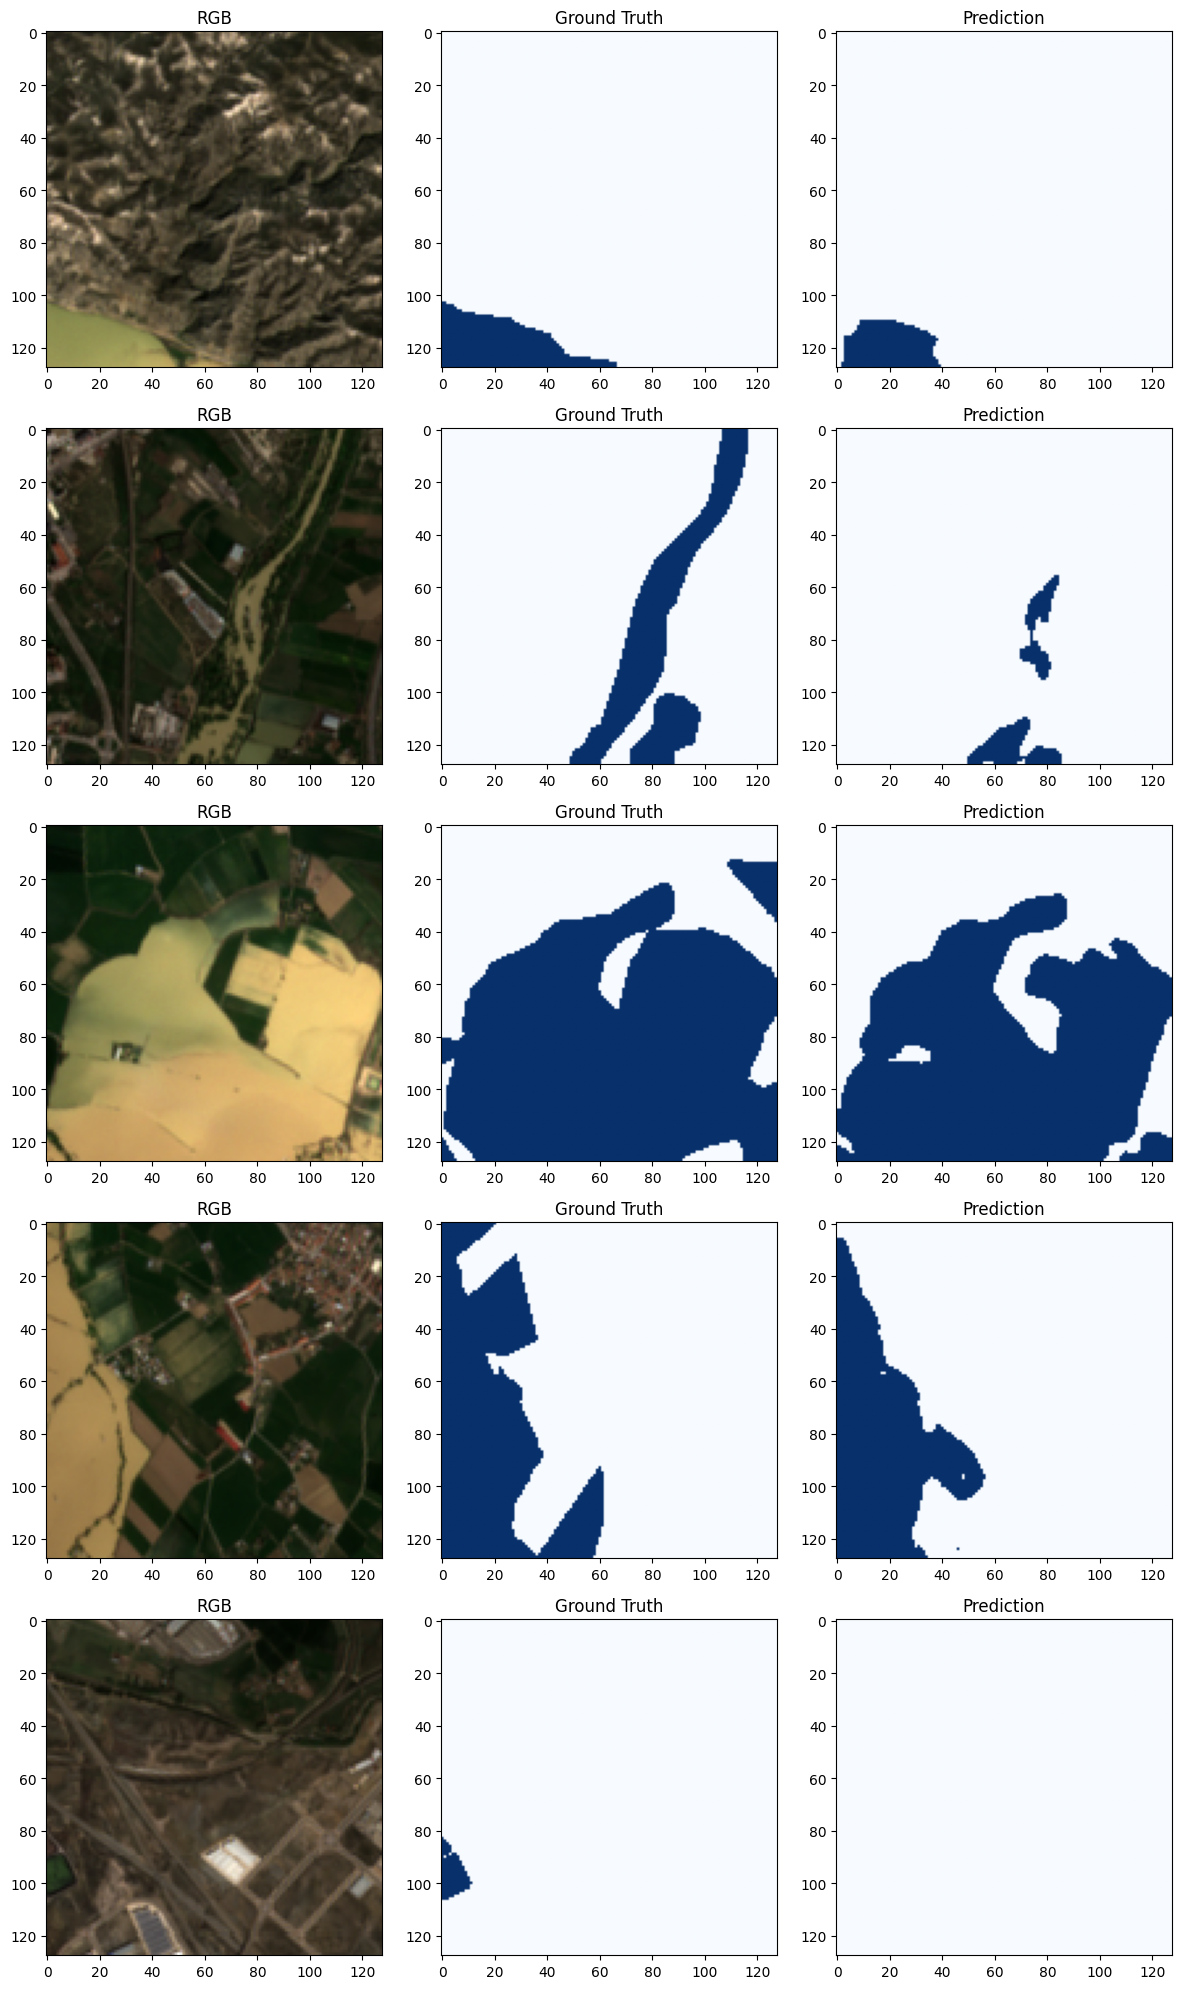

In [135]:
visualize_predictions(
    model,
    test_dataset,
    DEVICE
)